<a href="https://colab.research.google.com/github/Aryansaini-10/FUTURE_ML_01/blob/main/sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
from google.colab import files
import io

# This will open a file browser for you to select and upload your CSV file
uploaded = files.upload()

# Get the name of the uploaded file
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Read the uploaded CSV file into a pandas DataFrame
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

# Display the first 5 rows of the DataFrame
display(df.head())

Saving Walmart.csv to Walmart.csv
User uploaded file "Walmart.csv" with length 363732 bytes


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


Dataset Inspection

In [7]:
print("Shape:", df.shape)

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (6435, 8)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
None

Summary Statistics:
             Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      

Converting Date Column

In [8]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

In [9]:
# dropng orignal date
df.drop('Date', axis=1, inplace=True)

Exploratory Data Analysis (EDA)

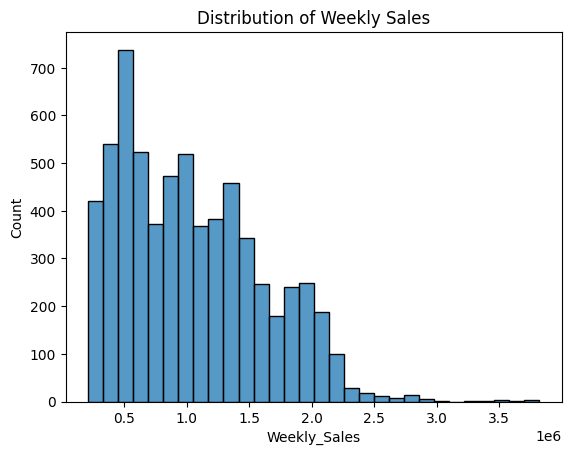

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

#Sales Distribution
plt.figure()
sns.histplot(df['Weekly_Sales'], bins=30)
plt.title("Distribution of Weekly Sales")
plt.show()

Defining Features and Targets

In [12]:
X = df.drop("Weekly_Sales", axis=1)

y = df["Weekly_Sales"]

Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

 Model trainnig

In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [33]:
#Adding Random Forest Model.
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest R2 Score:", r2_score(y_test, pred_rf))

Random Forest R2 Score: 0.9599962586240715


Making Predictions

In [15]:
y_pred = model.predict(X_test)

Model Evaluation

In [16]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 272049348139.45193
R2 Score: 0.15553160499602847


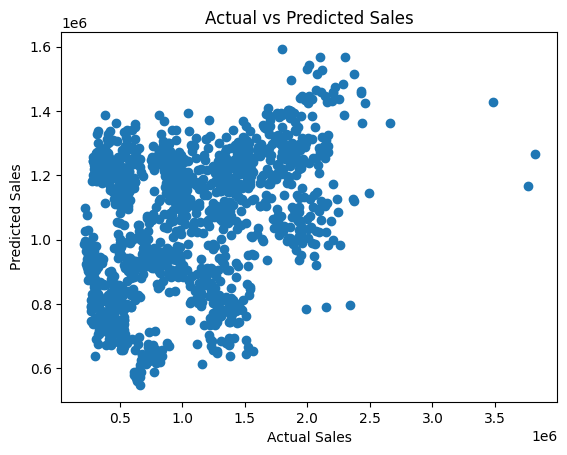

In [17]:
#actual vs pridicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

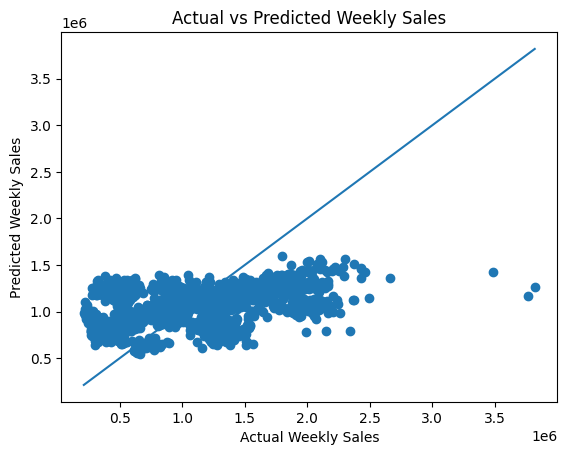

In [18]:
#Actual vs Predicted Sales Graph
plt.figure()

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs Predicted Weekly Sales")

plt.show()

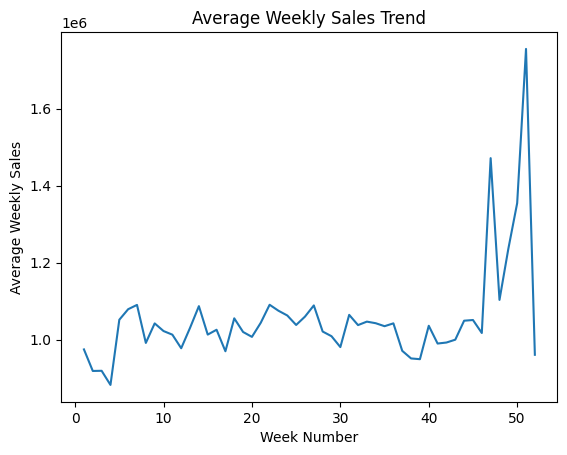

In [27]:
# Weekly Sales Trend (Time Series Insight)
# This shows how sales change over time
# analysis. %% Adding Random Forest Model.
plt.figure()

sales_trend = df.groupby('Week')['Weekly_Sales'].mean()

sales_trend.plot()

plt.title("Average Weekly Sales Trend")
plt.xlabel("Week Number")
plt.ylabel("Average Weekly Sales")

plt.show()
# This visualization shows how average weekly sales vary throughout the year,
#  helping identify seasonal patterns and sales fluctuations.

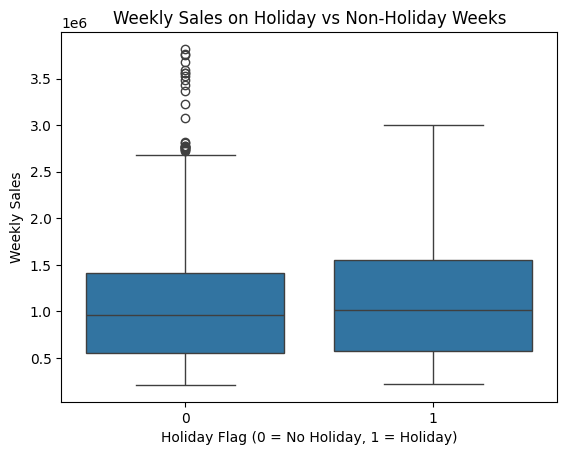

In [28]:
# Holiday vs Non-Holiday Sales
# The boxplot compares sales during holiday and non-holiday weeks. It helps
# understand whether holidays significantly impact retail sales. %% Adding
# Random Forest Model.
plt.figure()

sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df)

plt.title("Weekly Sales on Holiday vs Non-Holiday Weeks")
plt.xlabel("Holiday Flag (0 = No Holiday, 1 = Holiday)")
plt.ylabel("Weekly Sales")

plt.show()

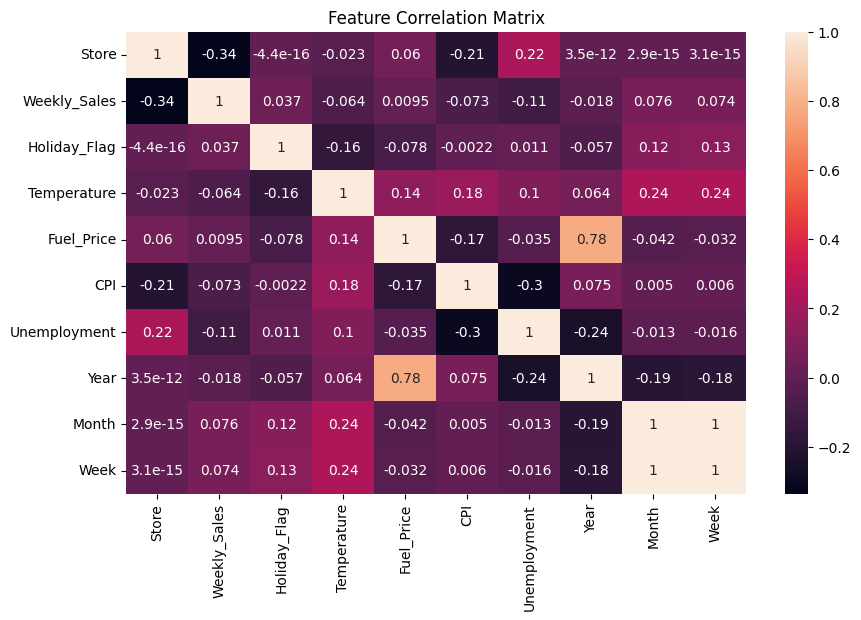

In [29]:
# Correlation Heatmap (Feature Relationships
# The heatmap visualizes correlations between variables such as temperature,
# fuel price, CPI, and unemployment with weekly sales. %% Adding Random Forest
# Model.
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True)

plt.title("Feature Correlation Matrix")

plt.show()

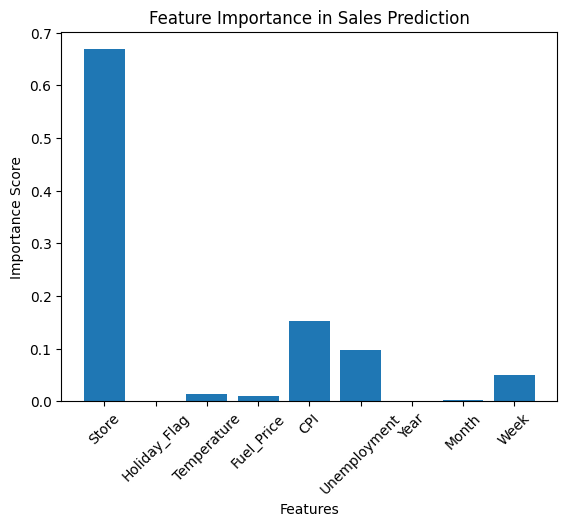

In [30]:
# Feature Importance (Advanced ML Insight)
# Feature importance analysis reveals which variables contribute most to
# predicting weekly sales. %% Adding Random Forest Model.
importance = rf.feature_importances_

features = X.columns

plt.figure()

plt.bar(features, importance)

plt.xticks(rotation=45)

plt.title("Feature Importance in Sales Prediction")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

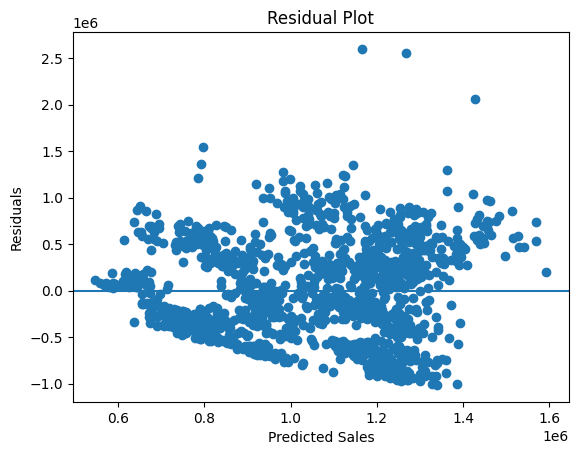

In [31]:
#Residual Plot (Model Performance)
# The residual plot helps evaluate model performance by showing prediction
# errors. %% Adding Random Forest Model.
residuals = y_test - y_pred

plt.figure()

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [32]:
#The trained machine learning model was saved using Pickle so that it can be reused for future predictions without retraining.
import pickle

with open("sales_prediction_model.pkl", "wb") as f:
    pickle.dump(rf, f)